In [1]:
import torch
from torch import nn, Tensor
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
import numpy as np
from flow_matching.solver import ODESolver
from torch.utils.data import TensorDataset, DataLoader

import sys
sys.path.append('./Textual-Anomaly-Detection-Framework/Anomaly Detection Framework')
import Modelisation.evaluation as ev
from utils import load_data_inlier, load_data_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Model

In [324]:
class FlowMatching(nn.Module):
    def __init__(self, source, target, input_dim=64, latent_dim=256, device='cuda', seed=42):
        super().__init__()
        
        self.seed = seed
        self.target = target
        self.source = source
        self.device = device
            
        if self.source == 'target-noised':
            noise = torch.randn(self.target.shape[0], self.target.shape[1])
            self.target_noised = self.target + noise
            
        if self.source == 'point-mean':
            self.point_mean = self.target.mean(dim=0).to(self.device)            
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, latent_dim), nn.ELU(),
            nn.Linear(latent_dim, input_dim)
        )

    def forward(self, x, t):
        t = t.expand(x.shape[0], 1)            
        xt = torch.cat([x, t], dim=1)

        return self.net(xt)
    
    def sampling_source(self, n_samples):

        
        if self.source == 'gaussian':
            return torch.randn(n_samples, self.input_dim).to(self.device)
    
        if self.source == 'circle': return Tensor(make_circles(n_samples=n_samples, noise=0.05, factor=0.95)[0]).to(self.device)
    
        if self.source == 'poisson': return Tensor(np.random.poisson(5, (n_samples, self.input_dim))).to(self.device)
    
        if self.source == 'uniform': return Tensor(np.random.uniform(low=self.target.min(), high=self.target.max(), size=(n_samples, self.input_dim))).to(self.device)
    
        if self.source == 'sphere':
            
            z = torch.randn(n_samples, self.input_dim)
            return Tensor(z / z.norm(dim=1, keepdim=True)).to(self.device)
        
        if self.source == 'sphere-noised':
            z = torch.randn(n_samples, self.input_dim)
                   
            z = z / z.norm(dim=1, keepdim=True)
            noise = torch.randn_like(z) * 0.25
            return Tensor(z + noise).to(self.device)
        
        if self.source == 'point-mean':
            # return self.point_mean.repeat(n_samples).reshape(-1,self.input_dim)
            return Tensor(np.array([0, 0]).repeat(n_samples).reshape(-1,self.input_dim)).to(self.device)
            
        
    def interpolation(self, n_samples, x1=None):

        # source sampling
        x0 = self.sampling_source(n_samples)
        # target sampling ( get n_samples examples from the all target dataset )
        # replace --> avec ou sans remise
        if x1 is None : idx = np.random.choice(self.target.shape[0], n_samples, replace=True)
        
        if self.source == 'target-noised':
            noise = torch.randn(x1.shape[0], x1.shape[1]).to(self.device)
            x0 = x1 + noise
        
        if x1 is None : x1 = self.target[idx].to(self.device)

        # sampling the time between 0 ad 1
        t = torch.rand(n_samples, 1).to(self.device)
        # t = torch.rand(n_samples).to(self.device)

        xt = (1 - t) * x0 + t * x1
        ut = x1 - x0
        
        return xt, t, ut

## Trainer

In [300]:
class FlowMatchingTrainer():
    def __init__(self, flow_model,  verbose=True):

        self.flow_model = flow_model
        self.verbose = verbose

    def train(self, dataloader, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam'):
        
        if optimizer_type == 'adam':
            optimizer = torch.optim.Adam(self.flow_model.parameters(), lr=lr, weight_decay=weight_decay)

        for s in range(n_epochs):

            for data, in dataloader:

                xt, t, ut = self.flow_model.interpolation(data.shape[0], data)
                vt =  self.flow_model(xt, t)

                optimizer.zero_grad()

                loss = loss_fn(vt, ut)
                loss.backward()

                optimizer.step()
            
            if self.verbose and s % (n_epochs // 5) == 0:
                print(f" step {s} -> loss : {loss.item():.5f}")
                
        return self.flow_model

    def forward_flow(self, x_0, solver_type='midpoint', n_steps=10):
            
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target = solver.sample(x_init=x_0, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target

    def backward_flow(self,x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_target_to_source
    
    def forward_backward_flow(self, x_1, solver_type='midpoint', n_steps=10):
        solver = ODESolver(velocity_model=self.flow_model)

        time_steps = torch.linspace(1.0, 0.0, n_steps)
        x_inter_target_to_source = solver.sample(x_init=x_1, method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        time_steps = torch.linspace(0.0, 1.0, n_steps)
        x_inter_source_to_target_recons = solver.sample(x_init=x_inter_target_to_source[-1], method=solver_type, step_size=1.0 / n_steps, time_grid=time_steps, return_intermediates=True)

        return x_inter_source_to_target_recons


    def test(self, X_test, y_test, score_type='norm', solver_type='midpoint', n_steps=10):

        if score_type == 'norm':
            x_source_after_backward = self.backward_flow(X_test, solver_type, n_steps)[-1].cpu().detach()
            # scores = ((x_source_after_backward - self.flow_model.target_centroid) ** 2).sum(dim=1)
            scores = (x_source_after_backward ** 2).sum(dim=1)

        if score_type == 'recons':
            x_target_after_forward_backward = self.forward_backward_flow(X_test, solver_type, n_steps)[-1]
            scores = ((torch.norm(x_target_after_forward_backward - X_test, dim=1)** 2)).cpu().detach()
 
        # auc = roc_auc_score(y_test, scores)
        # ap = average_precision_score(y_test, scores)
        # fpr, tpr, thresholds = roc_curve(y_test, scores)
        # idx = np.where(tpr >= 0.95)[0][0]
        # fpr95 = fpr[idx]

        auc, fpr95, ap = ev.evaluation(y_test, scores, verbose=False)

        print(f"FM --> AUC: {auc:.4f} | FPR@95: {fpr95:.4f} | AP: {ap:.4f}")  

        return auc, fpr95, ap 

## Data

In [399]:
inlier_topic = 'earn'
dataset_name = 'reuters'
type_tac = 'ruff'
anomaly_rate = 0.1
save_dir = "/home/2017025/ayouce01/Textual-Anomaly-Detection-Framework/Anomaly Detection Framework/Data"
n_run = 9

data_train = load_data_inlier(dataset_name, inlier_topic, save_dir, is_infec=False, is_cvdd=True)
data_test = load_data_test(dataset_name, inlier_topic, n_run, save_dir, is_cvdd=True)

print(data_train)
print(data_test)

X_inlier = Tensor(data_train['sbert_embeddings']).to(device)
X_test =  Tensor(data_test['sbert_embeddings']).to(device)
y_test = np.array(data_test['anomaly_class'])

Dataset({
    features: ['text', 'text_type', 'topics', 'lewis_split', 'cgis_split', 'old_id', 'new_id', 'places', 'people', 'orgs', 'exchanges', 'date', 'title', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 2556
})
Dataset({
    features: ['text', 'text_type', 'topics', 'lewis_split', 'cgis_split', 'old_id', 'new_id', 'places', 'people', 'orgs', 'exchanges', 'date', 'title', 'anomaly_class', 'sbert_embeddings'],
    num_rows: 1083
})


## Run

In [404]:
batch_size = 128
X_inlier_dl = DataLoader(TensorDataset(X_inlier), batch_size=batch_size, shuffle=True)

input_dim = X_inlier.shape[1]
latent_dim = 256
lr = 1e-4
weight_decay = 1e-4
n_epochs = 30

target = X_inlier.cpu()
source = 'target-noised'

flow_model = FlowMatching(source, target, input_dim, latent_dim, device).to(device)
optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = nn.MSELoss()

fm_trainer = FlowMatchingTrainer(flow_model, verbose=True)

flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

auc, fpr95, ap = fm_trainer.test(X_test, y_test, score_type='recons', solver_type='midpoint', n_steps=10)

 step 0 -> loss : 1.00360
 step 6 -> loss : 0.97410
 step 12 -> loss : 0.96379
 step 18 -> loss : 0.94709
 step 24 -> loss : 0.93243
FM --> AUC: 0.9094 | FPR@95: 0.3210 | AP: 0.4846


In [343]:
x_inter_target_to_source = fm_trainer.backward_flow(X_test)[-1]
scores = (x_inter_target_to_source ** 2).sum(dim=1)

In [295]:
y_test[(scores == scores.max()).cpu()]

array([0])

In [155]:
x_inter_target_to_source_inlier = x_inter_target_to_source[:, y_test == 0, :]
x_inter_target_to_source_inlier.shape

torch.Size([10, 627, 768])

In [156]:
x_inter_target_to_source_anomaly = x_inter_target_to_source[:, y_test == 1, :]
x_inter_target_to_source_anomaly.shape

torch.Size([10, 69, 768])

In [158]:
x_inter_target_to_source_inlier[0]

tensor([[-0.0185, -0.0375,  0.0148,  ..., -0.0188,  0.0405,  0.0047],
        [-0.0068, -0.0157, -0.0210,  ..., -0.0329, -0.0076,  0.0503],
        [ 0.0050, -0.0123, -0.0014,  ..., -0.0271,  0.0162,  0.0354],
        ...,
        [ 0.0147, -0.0256,  0.0015,  ...,  0.0016, -0.0266,  0.0604],
        [-0.0004, -0.0080,  0.0230,  ..., -0.0547,  0.0043,  0.0025],
        [-0.0048,  0.0063, -0.0254,  ..., -0.0299,  0.0114, -0.0157]],
       device='cuda:0')

In [159]:
x_inter_target_to_source_anomaly[0]

tensor([[-0.0183, -0.0074, -0.0272,  ...,  0.0130, -0.0192, -0.0036],
        [ 0.0254, -0.0422,  0.0191,  ..., -0.0930,  0.0021,  0.0327],
        [ 0.0087, -0.0329,  0.0041,  ..., -0.0219, -0.0706,  0.0123],
        ...,
        [-0.0016,  0.0035,  0.0076,  ..., -0.0435, -0.0156,  0.0049],
        [-0.0055, -0.0470, -0.0403,  ..., -0.0511,  0.0252,  0.0305],
        [ 0.0017, -0.0732,  0.0173,  ..., -0.0658, -0.0508,  0.0561]],
       device='cuda:0')

In [142]:
point_idx = 7
traj_point = x_inter_target_to_source[:, point_idx, :]

In [148]:
X_test[y_test == 0]

tensor([[-0.0185, -0.0375,  0.0148,  ..., -0.0188,  0.0405,  0.0047],
        [-0.0068, -0.0157, -0.0210,  ..., -0.0329, -0.0076,  0.0503],
        [ 0.0050, -0.0123, -0.0014,  ..., -0.0271,  0.0162,  0.0354],
        ...,
        [ 0.0147, -0.0256,  0.0015,  ...,  0.0016, -0.0266,  0.0604],
        [-0.0004, -0.0080,  0.0230,  ..., -0.0547,  0.0043,  0.0025],
        [-0.0048,  0.0063, -0.0254,  ..., -0.0299,  0.0114, -0.0157]],
       device='cuda:0')

## Toy Example

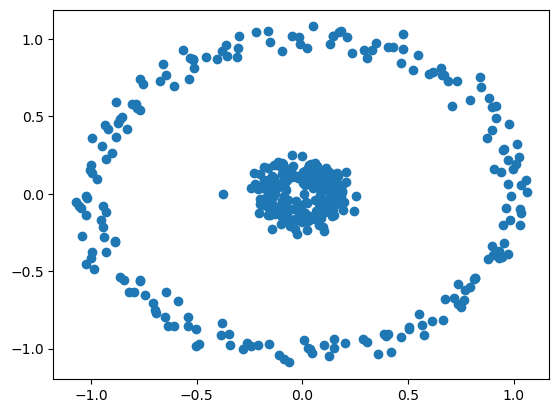

In [454]:
# a = np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])
a = np.concatenate([make_circles(400, noise=0.05, factor=0.15)[0] , torch.randn(0, 2)])
plt.scatter(a[:,0], a[:,1])

In [478]:
batch_size = 256
# X_train = TensorDataset(Tensor(np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])).to(device))
# X_train = TensorDataset(Tensor(make_moons(256, noise=0.05)[0]).to(device))
X_train = Tensor(make_circles(noise=0.05, factor=0.15)[0]).to(device)
# X_train = Tensor(np.array([0, 0]).repeat(300).reshape(-1,2)).to(device)
# X_train = Tensor(torch.randn(300, 2)).to(device)
X_inlier_dl = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)

input_dim = 2
latent_dim = 64
lr = 1e-2
weight_decay = 0
n_epochs = 10000

target = X_train.cpu()
source = 'gaussian'

flow_model = FlowMatching(source, target, input_dim, latent_dim, device).to(device)
optimizer = torch.optim.Adam(flow_model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = nn.MSELoss()

fm_trainer = FlowMatchingTrainer(flow_model, verbose=True)

flow_model_trained = fm_trainer.train(X_inlier_dl, lr, weight_decay, loss_fn, n_epochs, optimizer_type='adam')

 step 0 -> loss : 1.28300
 step 2000 -> loss : 0.85355
 step 4000 -> loss : 0.75741
 step 6000 -> loss : 0.84877
 step 8000 -> loss : 0.71932


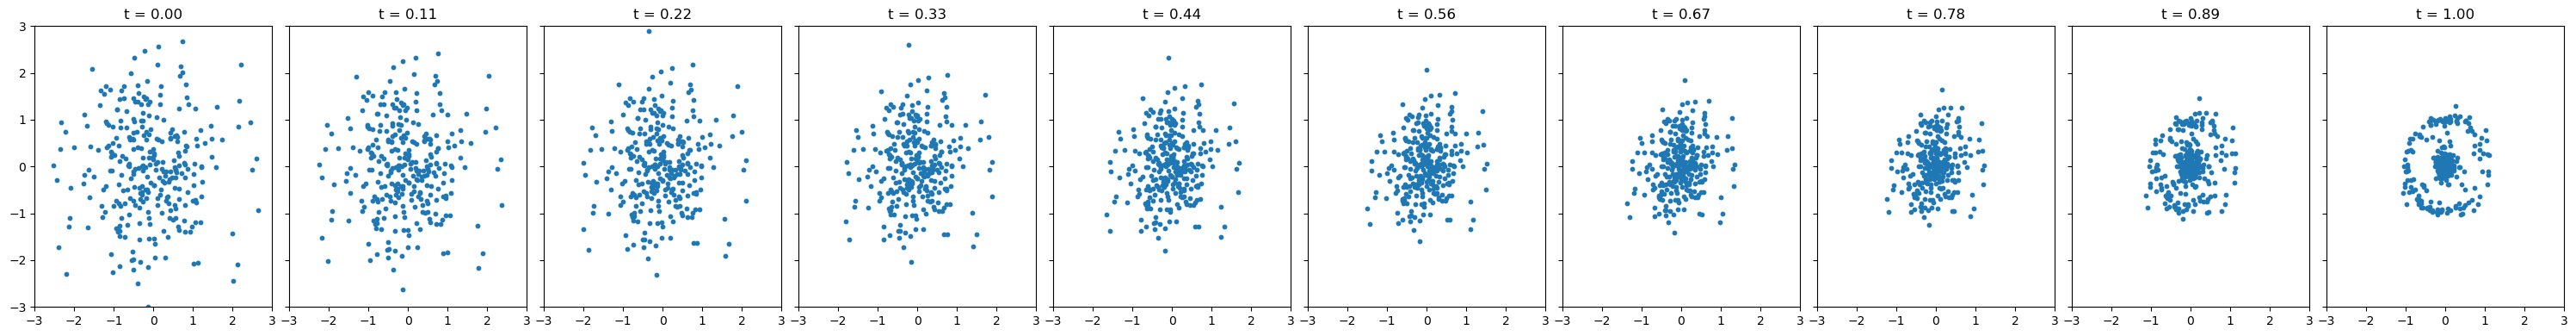

In [479]:
# x_0 = torch.randn(300, 2).to(device)
# x_0 = Tensor(np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])).to(device)
# x_0 = Tensor(np.concatenate([make_circles(n_samples=300, noise=0.05, factor=0.95)[0] , torch.randn(30, 2)])).to(device)
x_0 = flow_model_trained.sampling_source(300)
# x_0 = Tensor([0]).to(device)
x_inter_source_to_target = fm_trainer.forward_flow(x_0)

n_steps = x_inter_source_to_target.shape[0]

fig, axes = plt.subplots(1, n_steps, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps)

for i in range(n_steps):
    axes[i].scatter(
        x_inter_source_to_target[i, :, 0].cpu(),
        x_inter_source_to_target[i, :, 1].cpu(),
        s=10
    )
    axes[i].set_title(f't = {time_steps[i]:.2f}')
    axes[i].set_xlim(-3.0, 3.0)
    axes[i].set_ylim(-3.0, 3.0)

plt.tight_layout()
plt.show()


In [476]:
# x_1 = Tensor(make_moons(300, noise=0.05)[0]).to(device)
x_1 = Tensor(make_circles(n_samples=300, noise=0.05, factor=0.15)[0]).to(device)
# x_1 = Tensor(np.array([0, 0]).repeat(300).reshape(-1,2)).to(device)
# x_1 = Tensor(torch.randn(300, 2)).to(device)
# x_1 = Tensor(np.concatenate([make_moons(300, noise=0.05)[0] , torch.randn(30, 2)])).to(device)
x_inter_target_to_source = fm_trainer.backward_flow(x_1)

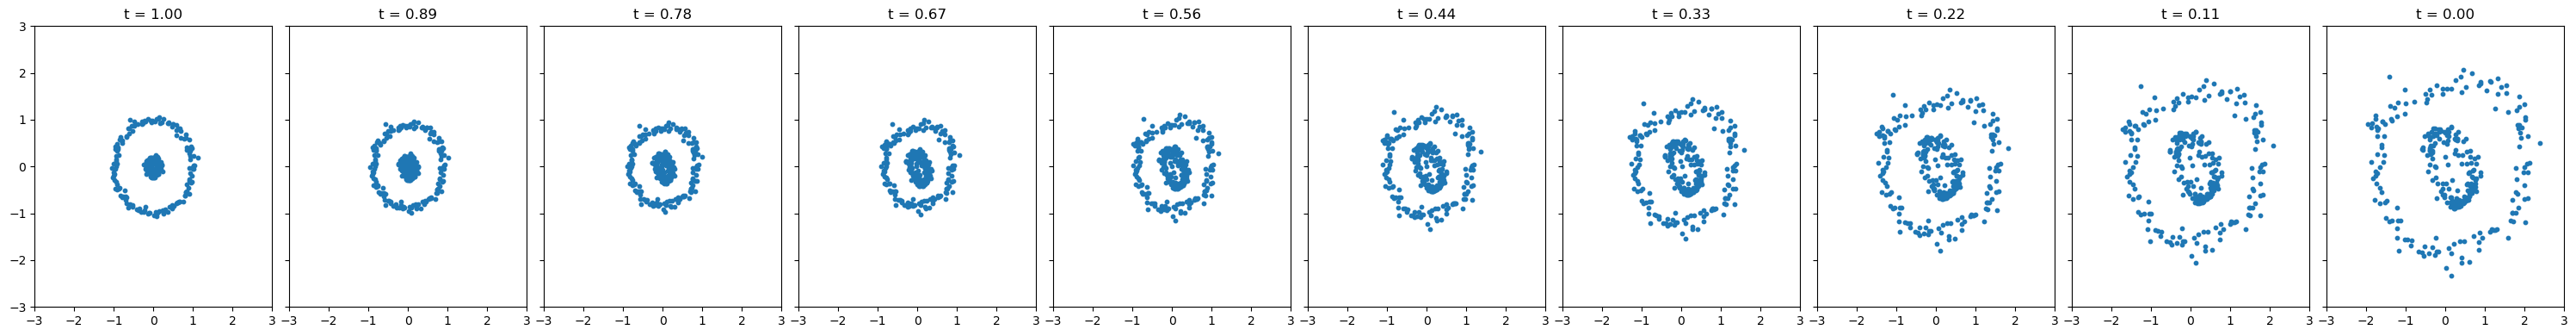

In [477]:
n_steps = x_inter_target_to_source.shape[0]

fig, axes = plt.subplots(1, n_steps, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(1., 0.0, n_steps)

for i in range(n_steps):
    axes[i].scatter(
        x_inter_target_to_source[i, :, 0].cpu(),
        x_inter_target_to_source[i, :, 1].cpu(),
        s=10
    )
    axes[i].set_title(f't = {time_steps[i]:.2f}')
    axes[i].set_xlim(-3.0, 3.0)
    axes[i].set_ylim(-3.0, 3.0)

plt.tight_layout()
plt.show()


In [426]:
@torch.no_grad()
def get_point_velocity(model, traj_point, device):
    
    velocities = []

    for i in range(traj_point.shape[0]):
        x = traj_point[i].unsqueeze(0).to(device)  
        t = torch.tensor([[i / (traj_point.shape[0] - 1)]], device=device)
        v = model(x, t) 
        velocities.append(v.cpu().squeeze(0))

    return torch.stack(velocities)

In [447]:
point_idx = 18
traj_point = x_inter_source_to_target[:, point_idx, :]

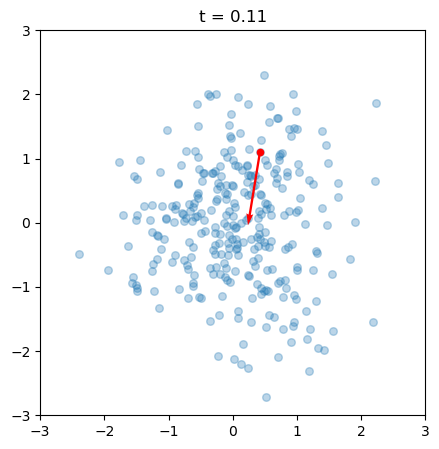

In [448]:
t_idx = 1
vel_point = get_point_velocity(flow_model_trained, traj_point, device)

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(
    x_inter_source_to_target[t_idx, :, 0].cpu(),
    x_inter_source_to_target[t_idx, :, 1].cpu(),
    s=30,
    alpha=0.3
)

x, y = traj_point[t_idx].cpu()
vx, vy = vel_point[t_idx].cpu()

ax.scatter(x, y, c="red", s=20, zorder=3)

ax.quiver(
    x, y,
    vx, vy,
    angles="xy",
    scale_units="xy",
    scale=1.0,
    color="red",
    width=0.006,
    zorder=4
)

ax.set_title(f"t = {t_idx / 9:.2f}")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect("equal")

plt.show()

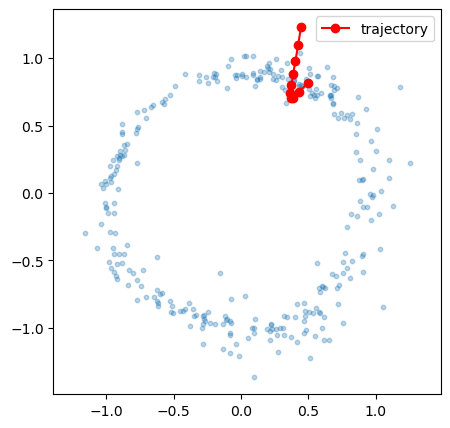

In [449]:
plt.figure(figsize=(5, 5))

plt.scatter(
    x_inter_source_to_target[-1, :, 0].cpu(),
    x_inter_source_to_target[-1, :, 1].cpu(),
    s=10, alpha=0.3
)

plt.plot(
    traj_point[:, 0].cpu(),
    traj_point[:, 1].cpu(),
    "-o",
    c="red",
    label="trajectory"
)

plt.legend()
plt.axis("equal")
plt.show()

## AEFM